# Portfolio 1

## Evaluatie van rule-based agents in Connect Four

In dit notebook worden verschillende rule-based agents met elkaar vergeleken binnen de Connect Four omgeving (PettingZoo).

De volgende agents worden getest:
- Baseline agent
- Blocking agent
- ForkBuilder agent
- HorizontalPreference agent
- MiddleFirst agent

Het doel is om inzicht te krijgen in de prestaties van deze agents door middel van simulaties en visualisaties.

In [15]:
#import sys
#!"{sys.executable}" -m pip install pettingzoo chess pygame numpy matplotlib ipykernel

In [ ]:
#libraries importeren
from pettingzoo.classic import connect_four_v3
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [3]:
env = connect_four_v3.env(render_mode="human")
env.reset()

for agent in env.agent_iter():

    observation, reward, termination, truncation, info = env.last()

    if termination or truncation:
        action = None
    else:
        mask = observation["action_mask"]

        # kies eerste geldige zet
        legal_moves = [i for i, m in enumerate(mask) if m == 1]
        action = legal_moves[0]

    env.step(action)
    

In [4]:
def play_vs_agent(agent_ai):

    env = connect_four_v3.env(render_mode="human")
    env.reset()

    print(f"Je speelt tegen: {agent_ai.__class__.__name__}")

    for agent in env.agent_iter():

        observation, reward, termination, truncation, info = env.last()

        if termination or truncation:
            action = None
        else:
            mask = observation["action_mask"]
            legal_moves = [i for i, m in enumerate(mask) if m == 1]

            if agent == "player_0":
                # 👤 JIJ speelt
                print("\nJouw beurt!")
                print("Kies kolom (0-6): ", legal_moves)

                while True:
                    try:
                        action = int(input("Jouw zet: "))
                        if action in legal_moves:
                            break
                        else:
                            print("❌ Ongeldige zet, kies uit:", legal_moves)
                    except:
                        print("❌ Voer een getal in")

            else:
                # 🤖 AI speelt
                action = agent_ai.act(observation)
                print(f"AI ({agent_ai.__class__.__name__}) speelt kolom: {action}")

        env.step(action)

    env.close()

In [5]:
from baseline_agent import baseline
from BlockingAgent import BlockingAgent
from ForkBuilderAgent import ForkBuilderAgent
from horizontal_preference_agent import HorizontalPreferenceAgent
from MiddleFirstAgent import MiddleFirstAgent

play_vs_agent(baseline())
#play_vs_agent(BlockingAgent())
#play_vs_agent(ForkBuilderAgent())
#play_vs_agent(HorizontalPreferenceAgent())
#play_vs_agent(MiddleFirstAgent())

Je speelt tegen: baseline

Jouw beurt!
Kies kolom (0-6):  [0, 1, 2, 3, 4, 5, 6]
AI (baseline) speelt kolom: 2

Jouw beurt!
Kies kolom (0-6):  [0, 1, 2, 3, 4, 5, 6]
AI (baseline) speelt kolom: 1

Jouw beurt!
Kies kolom (0-6):  [0, 1, 2, 3, 4, 5, 6]
AI (baseline) speelt kolom: 1

Jouw beurt!
Kies kolom (0-6):  [0, 1, 2, 3, 4, 5, 6]
AI (baseline) speelt kolom: 2

Jouw beurt!
Kies kolom (0-6):  [0, 1, 2, 3, 4, 5, 6]
AI (baseline) speelt kolom: 2

Jouw beurt!
Kies kolom (0-6):  [0, 1, 2, 3, 4, 5, 6]
AI (baseline) speelt kolom: 2

Jouw beurt!
Kies kolom (0-6):  [0, 1, 2, 3, 4, 5, 6]
AI (baseline) speelt kolom: 6

Jouw beurt!
Kies kolom (0-6):  [0, 1, 3, 4, 5, 6]
AI (baseline) speelt kolom: 0

Jouw beurt!
Kies kolom (0-6):  [0, 1, 3, 4, 5, 6]
AI (baseline) speelt kolom: 0

Jouw beurt!
Kies kolom (0-6):  [1, 3, 4, 5, 6]
AI (baseline) speelt kolom: 1

Jouw beurt!
Kies kolom (0-6):  [1, 3, 4, 5, 6]
AI (baseline) speelt kolom: 1


## Simulatie van een spel

In deze sectie wordt een functie gedefinieerd die een spel tussen twee agents simuleert.

De agents spelen om en om een zet op basis van hun strategie. De uiteindelijke beloningen worden gebruikt om te bepalen wie het spel wint of dat het spel in een gelijkspel eindigt.

In [6]:
def play_game(agent1, agent2):

    env = connect_four_v3.env()
    env.reset()

    agents = {
        "player_0": agent1,
        "player_1": agent2
    }

    rewards = {"player_0": 0, "player_1": 0}

    for agent in env.agent_iter():

        observation, reward, termination, truncation, info = env.last()

        rewards[agent] += reward

        if termination or truncation:
            action = None
        else:
            action = agents[agent].act(observation)

        env.step(action)

    env.close()

    return rewards


## Evaluatie van agents

Hier wordt een functie geïmplementeerd die meerdere spellen tussen twee agents uitvoert.

Om eerlijke resultaten te verkrijgen, wisselen de agents van startpositie. Hierdoor wordt voorkomen dat één agent voordeel heeft doordat deze altijd als eerste speelt.

De functie retourneert het aantal wins, losses en draws.

In [7]:
def evaluate_agents(agentA, agentB, n_games=50):

    wins_A = 0
    wins_B = 0
    draws = 0

    for i in range(n_games):

        if i % 2 == 0:
            rewards = play_game(agentA, agentB)
            if rewards["player_0"] > rewards["player_1"]:
                wins_A += 1
            elif rewards["player_1"] > rewards["player_0"]:
                wins_B += 1
            else:
                draws += 1
        else:
            rewards = play_game(agentB, agentA)
            if rewards["player_0"] > rewards["player_1"]:
                wins_B += 1
            elif rewards["player_1"] > rewards["player_0"]:
                wins_A += 1
            else:
                draws += 1

    return wins_A, wins_B, draws


## Vergelijking van alle agents

In deze sectie worden alle agents tegen elkaar getest.

Voor elke combinatie van agents worden meerdere spellen gespeeld. De resultaten worden opgeslagen in matrices voor:
- Aantal wins
- Aantal draws
- Winrates

Deze matrices vormen de basis voor de visualisaties.

In [8]:
agents = {
    "Baseline": baseline(),
    "Blocking": BlockingAgent(),
    "ForkBuilder": ForkBuilderAgent(),
    "Horizontal": HorizontalPreferenceAgent(),
    "MiddleFirst": MiddleFirstAgent()
}

names = list(agents.keys())
n = len(names)

wins_matrix = np.zeros((n, n))
draws_matrix = np.zeros((n, n))
winrate_matrix = np.zeros((n, n))


In [9]:
for i, name1 in enumerate(names):
    for j, name2 in enumerate(names):

        print(f"{name1} vs {name2}")

        wins1, wins2, draws = evaluate_agents(
            agents[name1], agents[name2], n_games=50
        )

        wins_matrix[i][j] = wins1
        draws_matrix[i][j] = draws
        winrate_matrix[i][j] = wins1 / 50

Baseline vs Baseline
Baseline vs Blocking
BLOCK THREAT: [2]
BLOCK FORK: 3
WIN: 4
MUST BLOCK: [4]
BLOCK FORK: 2
BLOCK FORK: 2
WIN: 2
BLOCK FORK: 1
BLOCK FORK: 1
BLOCK FORK: 1
MUST BLOCK: [6]
MUST BLOCK: [6]
BLOCK FORK: 0
BLOCK FORK: 0
MUST BLOCK: [5]
MUST BLOCK: [5]
BLOCK FORK: 1
BLOCK FORK: 1
BLOCK FORK: 1
WIN: 1
BLOCK FORK: 2
BLOCK FORK: 0
BLOCK FORK: 0
BLOCK FORK: 0
MUST BLOCK: [6]
BLOCK FORK: 2
WIN: 3
BLOCK THREAT: [6]
BLOCK THREAT: [4, 6]
BLOCK THREAT: [4, 6]
BLOCK THREAT: [2, 4, 6]
MUST BLOCK: [6]
BLOCK FORK: 2
MUST BLOCK: [4]
MUST BLOCK: [4]
BLOCK FORK: 0
BLOCK FORK: 0
MUST BLOCK: [3]
MUST BLOCK: [3]
WIN: 5
WIN: 5
WIN: 5
BLOCK FORK: 0
WIN: 0
BLOCK FORK: 1
WIN: 1
WIN: 1
WIN: 4
WIN: 4
WIN: 4
BLOCK FORK: 3
BLOCK FORK: 1
MUST BLOCK: [1]
MUST BLOCK: [1]
MUST BLOCK: [1]
BLOCK FORK: 4
BLOCK FORK: 3
BLOCK FORK: 3
BLOCK FORK: 3
BLOCK FORK: 4
BLOCK FORK: 0
BLOCK FORK: 0
MUST BLOCK: [4, 5]
BLOCK THREAT: [3]
BLOCK THREAT: [3]
BLOCK THREAT: [0, 3]
BLOCK FORK: 2
BLOCK FORK: 2
BLOCK FORK: 2
WIN

## Visualisatie van resultaten

De prestaties van de agents worden gevisualiseerd met behulp van heatmaps.

De volgende visualisaties worden getoond:
- Aantal wins per agent
- Aantal draws per agent
- Winrate per agent

Deze grafieken maken het mogelijk om de prestaties en onderlinge verschillen tussen de agents snel te analyseren.

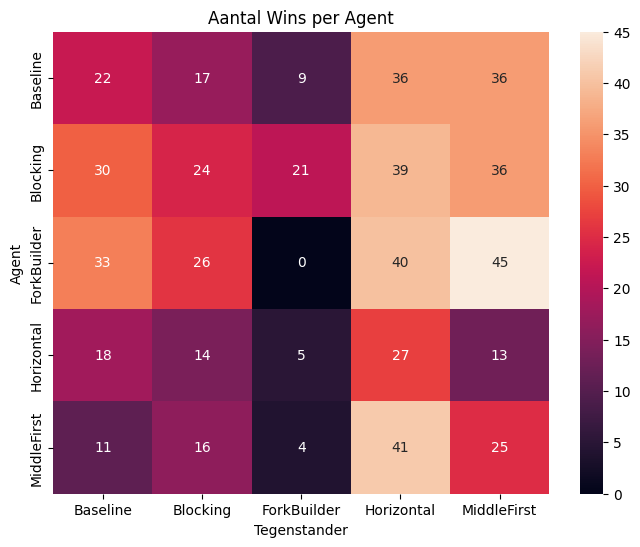

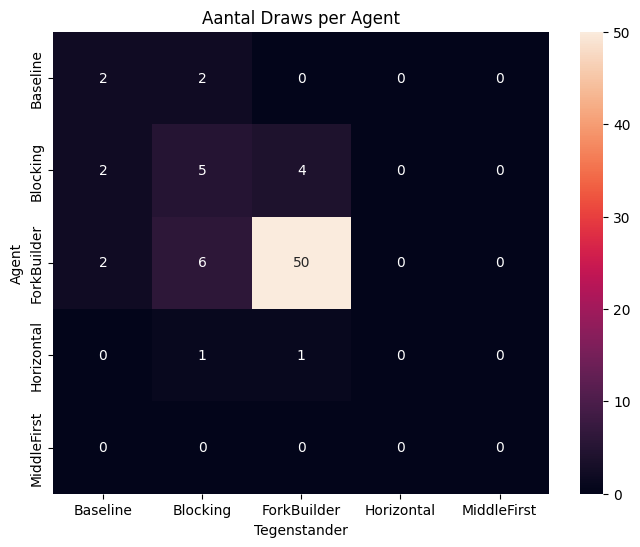

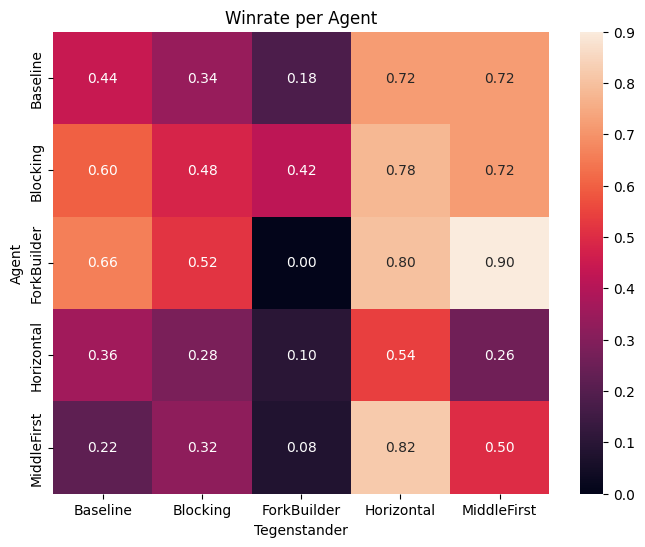

In [ ]:
# WINS
plt.figure(figsize=(8,6))
sns.heatmap(wins_matrix, annot=True, fmt=".0f",
            xticklabels=names, yticklabels=names)
plt.title("Aantal Wins per Agent")
plt.xlabel("Tegenstander")
plt.ylabel("Agent")
plt.show()


# DRAWS
plt.figure(figsize=(8,6))
sns.heatmap(draws_matrix, annot=True, fmt=".0f",
            xticklabels=names, yticklabels=names)
plt.title("Aantal Draws per Agent")
plt.xlabel("Tegenstander")
plt.ylabel("Agent")
plt.show()


# WINRATE
plt.figure(figsize=(8,6))
sns.heatmap(winrate_matrix, annot=True, fmt=".2f",
            xticklabels=names, yticklabels=names)
plt.title("Winrate per Agent")
plt.xlabel("Tegenstander")
plt.ylabel("Agent")
plt.show()

## Gemiddelde prestaties per agent

Naast de heatmaps wordt ook de gemiddelde winrate per agent weergegeven.

Hierbij worden wedstrijden tegen zichzelf buiten beschouwing gelaten, zodat een eerlijker beeld ontstaat van de prestaties tegen andere agents.

Deze grafiek geeft een duidelijk overzicht van welke agent overall het beste presteert.

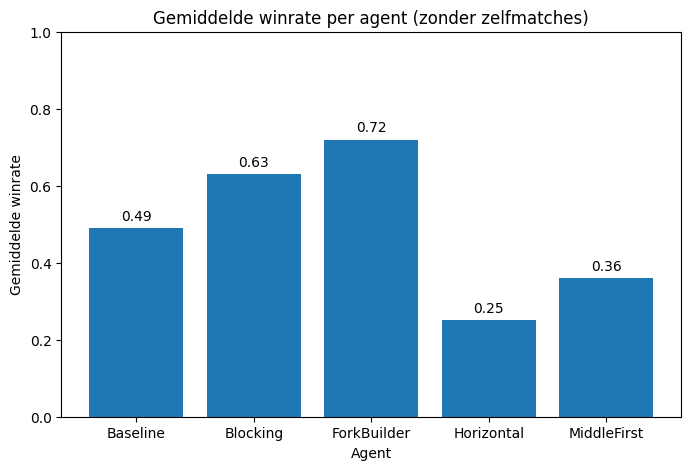

In [ ]:
avg_winrate_no_self = []

for i in range(len(names)):
    row = np.delete(winrate_matrix[i], i)
    avg_winrate_no_self.append(np.mean(row))

plt.figure(figsize=(8, 5))
bars = plt.bar(names, avg_winrate_no_self)

plt.title("Gemiddelde winrate per agent (zonder zelfmatches)")
plt.xlabel("Agent")
plt.ylabel("Gemiddelde winrate")
plt.ylim(0, 1)

for bar, value in zip(bars, avg_winrate_no_self):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{value:.2f}",
        ha="center"
    )

plt.show()